In [15]:
import numpy as np 
import pandas as pd
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson

import src.statistics.spline as spline
import src.analysis.plots as plots
import src.statistics.combination as comb

In [17]:
ROOT = Path('results')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [19]:
scale_cut = [1, 5]
data = np.load(ROOT/f'merged_res_norm_{scale_cut[0]}_{scale_cut[1]}_v4.npz')
names = ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']
print(data.files)

['1/npz_cross_z', '1/npz_cross', '1/npz_cross_err', '1/npz_bs_z', '1/npz_bs', '1/npz_bs_err', '1/npz_bs_bp_z', '1/npz_bs_bp', '1/npz_bs_bp_err', '1/npz_bs_bp_mag_z', '1/npz_bs_bp_mag', '1/npz_bs_bp_mag_err', '2/npz_cross_z', '2/npz_cross', '2/npz_cross_err', '2/npz_bs_z', '2/npz_bs', '2/npz_bs_err', '2/npz_bs_bp_z', '2/npz_bs_bp', '2/npz_bs_bp_err', '2/npz_bs_bp_mag_z', '2/npz_bs_bp_mag', '2/npz_bs_bp_mag_err', '3/npz_cross_z', '3/npz_cross', '3/npz_cross_err', '3/npz_bs_z', '3/npz_bs', '3/npz_bs_err', '3/npz_bs_bp_z', '3/npz_bs_bp', '3/npz_bs_bp_err', '3/npz_bs_bp_mag_z', '3/npz_bs_bp_mag', '3/npz_bs_bp_mag_err', '4/npz_cross_z', '4/npz_cross', '4/npz_cross_err', '4/npz_bs_z', '4/npz_bs', '4/npz_bs_err', '4/npz_bs_bp_z', '4/npz_bs_bp', '4/npz_bs_bp_err', '4/npz_bs_bp_mag_z', '4/npz_bs_bp_mag', '4/npz_bs_bp_mag_err']


In [20]:
tomo = 1
z = [data[f'{tomo}/{name}_z'] for name in names]
npz = [data[f'{tomo}/{name}'] for name in names]
npz_err = [data[f'{tomo}/{name}_err'] for name in names]

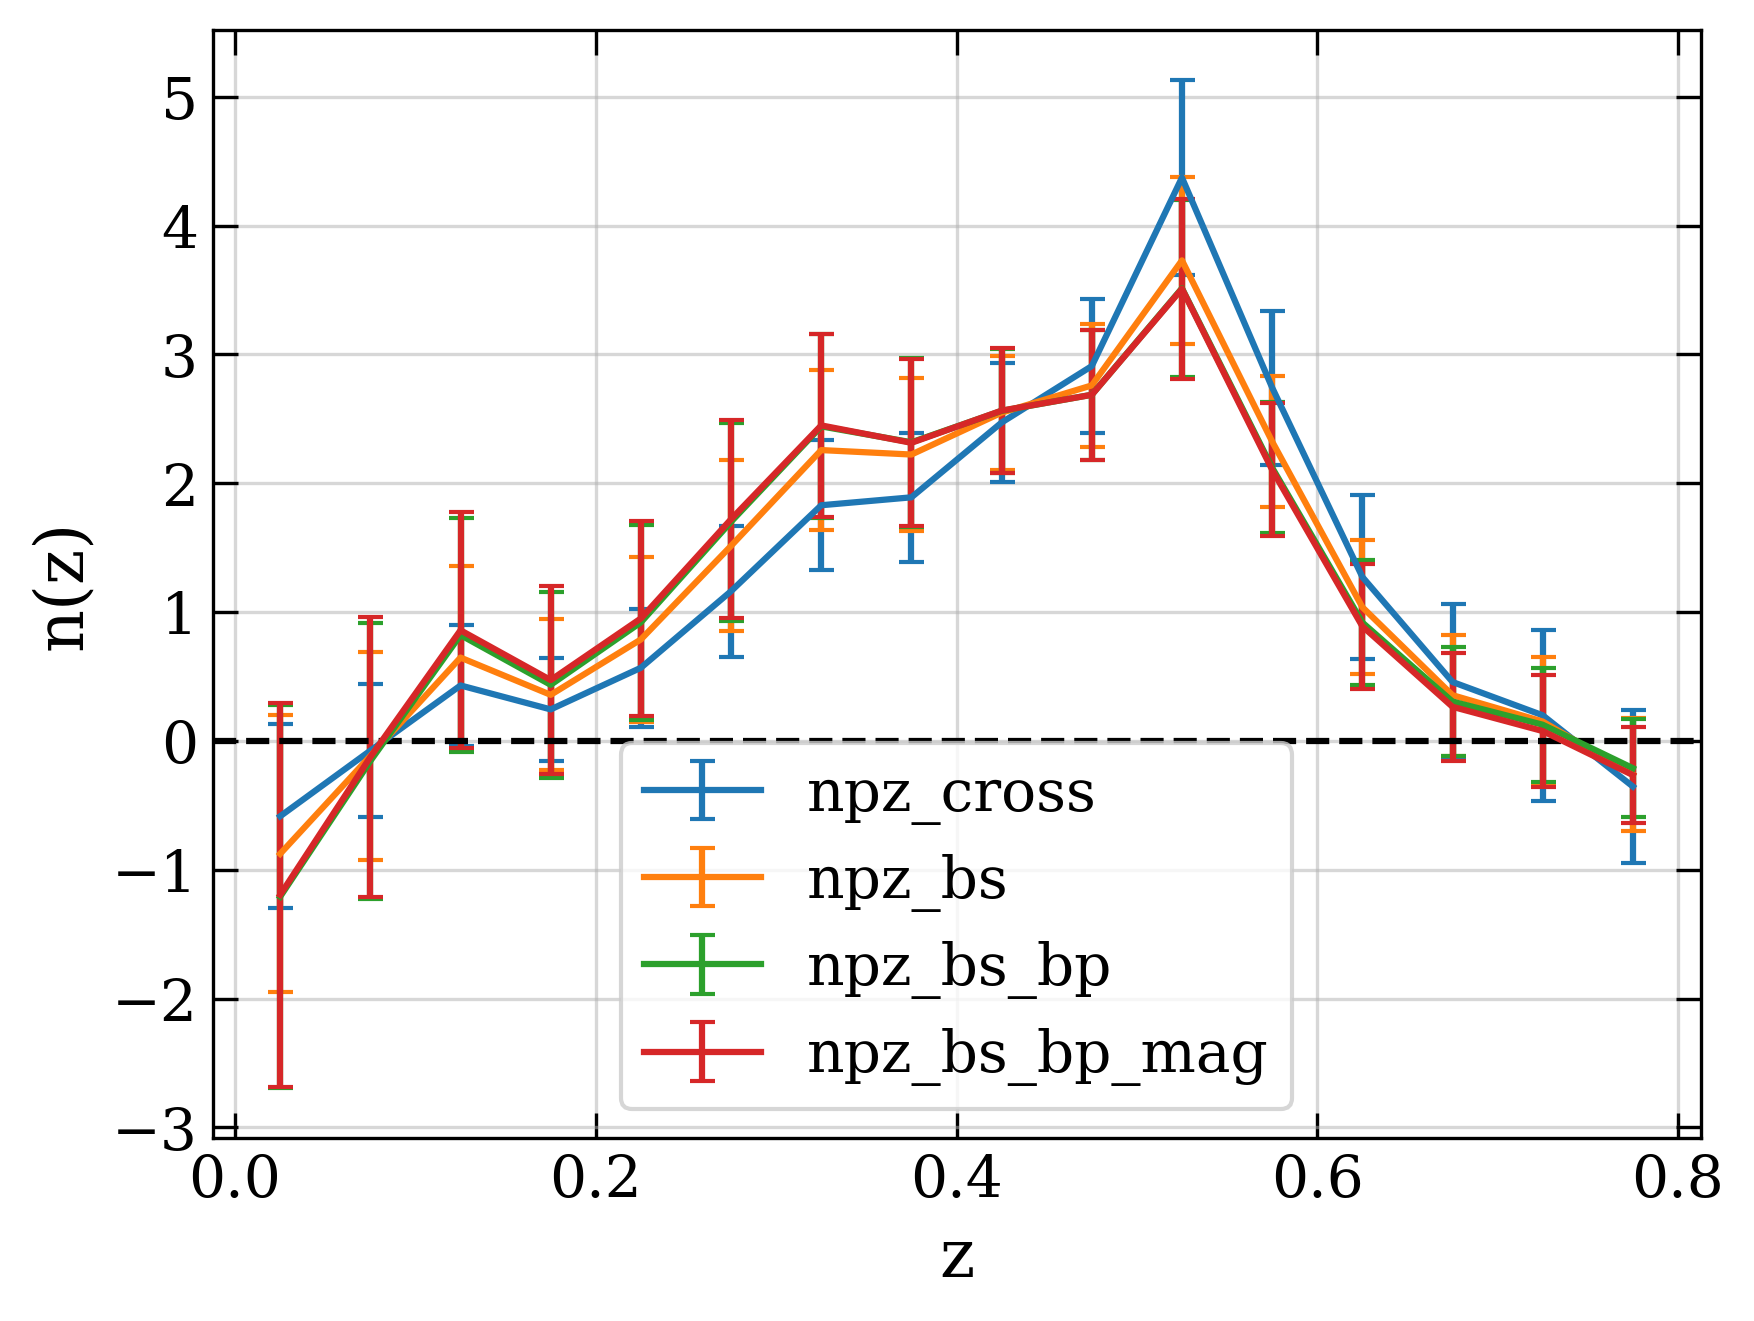

In [14]:
for i, name in enumerate(names):
    plt.errorbar(z[i], npz[i], npz_err[i], capsize=3, label=name)
plt.legend()
plt.grid(True)
plt.ylabel('n(z)')
plt.xlabel('z')
plt.axhline(0, color='black', linestyle='--')

In [21]:
s_data = {}
expect = {}
show_knots = False
z_all = np.linspace(0, 3, 1000)
names = ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']
name_to_label = {
    'npz_cross': 'no bias evolution',
    'npz_bs': r'with $b_s(z)$',
    'npz_bs_bp': r'with $b_p(z)$',
    'npz_bs_bp_mag': r'with $\mu$-correction'
}

for tomo in [1, 2, 3, 4]:
    spline_dict = {
        name : spline.BayesianBSpline.from_saved_model(f'results/splines_{scale_cut[0]}_{scale_cut[1]}_v5/spl_{name}_{tomo}') 
        for name in names
        }

    with pm.make_plot(f'nz_spline_tomo{tomo}', figsize=(9, 3.6), show=True) as (fig, ax_main):
        cmap = plt.get_cmap('plasma')
        markers = ['x', 's', '^', 'D']
        linestyles = ['-', '--', '-.', ':']

        for ind, name in enumerate(names):
            spl_study = spline_dict[name]

            mask = (z_all <= spl_study.zv.max()) & (z_all >= spl_study.zv.min())
            z_eval = z_all[mask]

            n_eval_points=200
            nz_samples = spl_study.get_samples(z_eval=z_eval, n_eval_points=n_eval_points)
            basis_eval = spl_study._create_evaluation_basis(z_eval)
            
            nz_median = np.percentile(nz_samples, 50, axis=0)
            norm_median = simpson(nz_median, z_eval)
            nz_samples_norm = nz_samples / simpson(nz_samples, z_eval, axis=1)[:, None]
            
            nz_median = np.percentile(nz_samples_norm, 50, axis=0)
            nz_mean = np.mean(nz_samples_norm, axis=0)
            nz_std = np.std(nz_samples_norm, axis=0)
            nz_lower = np.percentile(nz_samples_norm, 16, axis=0)
            nz_upper = np.percentile(nz_samples_norm, 84, axis=0)

            color = cmap((ind+1)/len(names))
            
            nz_median_all = np.zeros(len(z_all))
            nz_mean_all = np.zeros(len(z_all))
            nz_mean_all[mask] = nz_mean
            nz_median_all[mask] = nz_median
            nz_lower_all = np.zeros(len(z_all))
            nz_lower_all[mask] = nz_lower
            nz_upper_all = np.zeros(len(z_all))
            nz_upper_all[mask] = nz_upper
            
            s_data[f'z'] = z_all
            if (name == 'npz_bs_bp') or (name == 'npz_bs_bp_mag'):
                if 'mag' in name:
                    add = '_mu'
                else:
                    add = ''
                s_data[f'{tomo}/nz_median{add}'] = nz_median_all
                s_data[f'{tomo}/nz_mean{add}'] = nz_mean_all
                s_data[f'{tomo}/nz_lower{add}'] = nz_lower_all
                s_data[f'{tomo}/nz_upper{add}'] = nz_upper_all

            ax_main.errorbar(
                spl_study.zv+(0.005*(ind-1)), 
                spl_study.nz / norm_median, 
                yerr=spl_study.nz_err / norm_median,
                fmt=markers[ind], 
                color=color,
                alpha=0.7,
                capsize=3, 
                capthick=1, 
                )
            ax_main.plot(
                z_eval, 
                nz_median, 
                color=color, 
                alpha=1,
                linewidth=2, 
                linestyle=linestyles[ind],
                label=name_to_label[name]
                )
            ax_main.fill_between(
                z_eval, 
                nz_lower, 
                nz_upper, 
                color=color, 
                alpha=0.3, 
                )
            print('\n')
            print('Expectation')
            expect_samples = [np.trapezoid(nzsn * z_eval, z_eval) for nzsn in nz_samples_norm]
            percentiles = np.percentile(expect_samples, [16, 50, 84])
            print(f'16th, 50th, 84th percentiles: {percentiles}')
            expect_nz = np.trapezoid(nz_mean * z_eval, z_eval)
            print(f'Expectation from mean n(z): {expect_nz}') 
            print('\n')
            expect[f'{tomo}/{name}'] = percentiles
            expect[f'{tomo}/{name}_mean'] = expect_nz
                        
        ax_main.legend(fontsize=12.5, loc='upper left', framealpha=0.9)
        ax_main.text(
            0.82, 
            0.95, 
            f'Bin {tomo}\nz:{0.3*tomo:.1f}-{0.3*(tomo+1):.1f}', 
            transform=ax_main.transAxes,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
            fontsize=16
        )

        if show_knots:
            knot_positions = spl_study.knots[spl_study.degree:-spl_study.degree]
            for i, knot in enumerate(knot_positions):
                alpha_val = 0.6 if i == 0 else 0.4
                label_val = 'Knots' if i == 0 else None
                ax_main.axvline(knot, color='gray', linestyle='--', alpha=alpha_val, 
                            linewidth=1, label=label_val)

        ax_main.set_xlabel('Redshift (z)', fontsize=16)
        ax_main.set_ylabel(r'$n(z)$', fontsize=16)
        ax_main.axhline(0, color='black', linestyle='--')
        ax_main.grid(True, alpha=0.3)

FileNotFoundError: [Errno 2] No such file or directory: 'results/splines_1_5_v5/spl_npz_cross_1_meta.pkl'

In [ ]:
np.savez(ROOT / f'distributions_{scale_cut[0]}_{scale_cut[1]}_v5.npz', **s_data)
np.savez(ROOT / f'expectations_{scale_cut[0]}_{scale_cut[1]}_v5.npz', **expect)

In [37]:
tomo_bin_dnnz = np.loadtxt('pz/data/tomographic_binning_dnnz.dat')
mids = tomo_bin_dnnz[:, 0]

In [ ]:
splines_dict = {
    name : 
        {
            tomo : 
                spline.BayesianBSpline.from_saved_model(f'results/splines_{scale_cut[0]}_{scale_cut[1]}_v5/spl_{name}_{tomo}') 
                for tomo in [1,2,3,4]
            } 
        for name in names
        }

bounds = {
    '1' : (0, 0.9),
    '2' : (0.3, 1.3),
    '3' : (0.3, 2.1),
    '4' : (0.7, 2.1)
}
do_bounds = True
if not do_bounds:
    bounds = {
        f'{i}' : (0, 3) for i in range(1, 5)
    }

9.61765532977698
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_v4/spl_npz_cross_1.nc
  - Metadata: results/splines_0.3_3_v4/spl_npz_cross_1_meta.pkl
  - Posterior samples: 6400
9.772318170178332
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_v4/spl_npz_cross_2.nc
  - Metadata: results/splines_0.3_3_v4/spl_npz_cross_2_meta.pkl
  - Posterior samples: 6400
10.448242227709972
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_v4/spl_npz_cross_3.nc
  - Metadata: results/splines_0.3_3_v4/spl_npz_cross_3_meta.pkl
  - Posterior samples: 6400
9.9929338105073
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_v4/spl_npz_cross_4.nc
  - Metadata: results/splines_0.3_3_v4/spl_npz_cross_4_meta.pkl
  - Posterior samples: 6400
9.669562984452334
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/splines_0.3_3_v4/spl_npz_

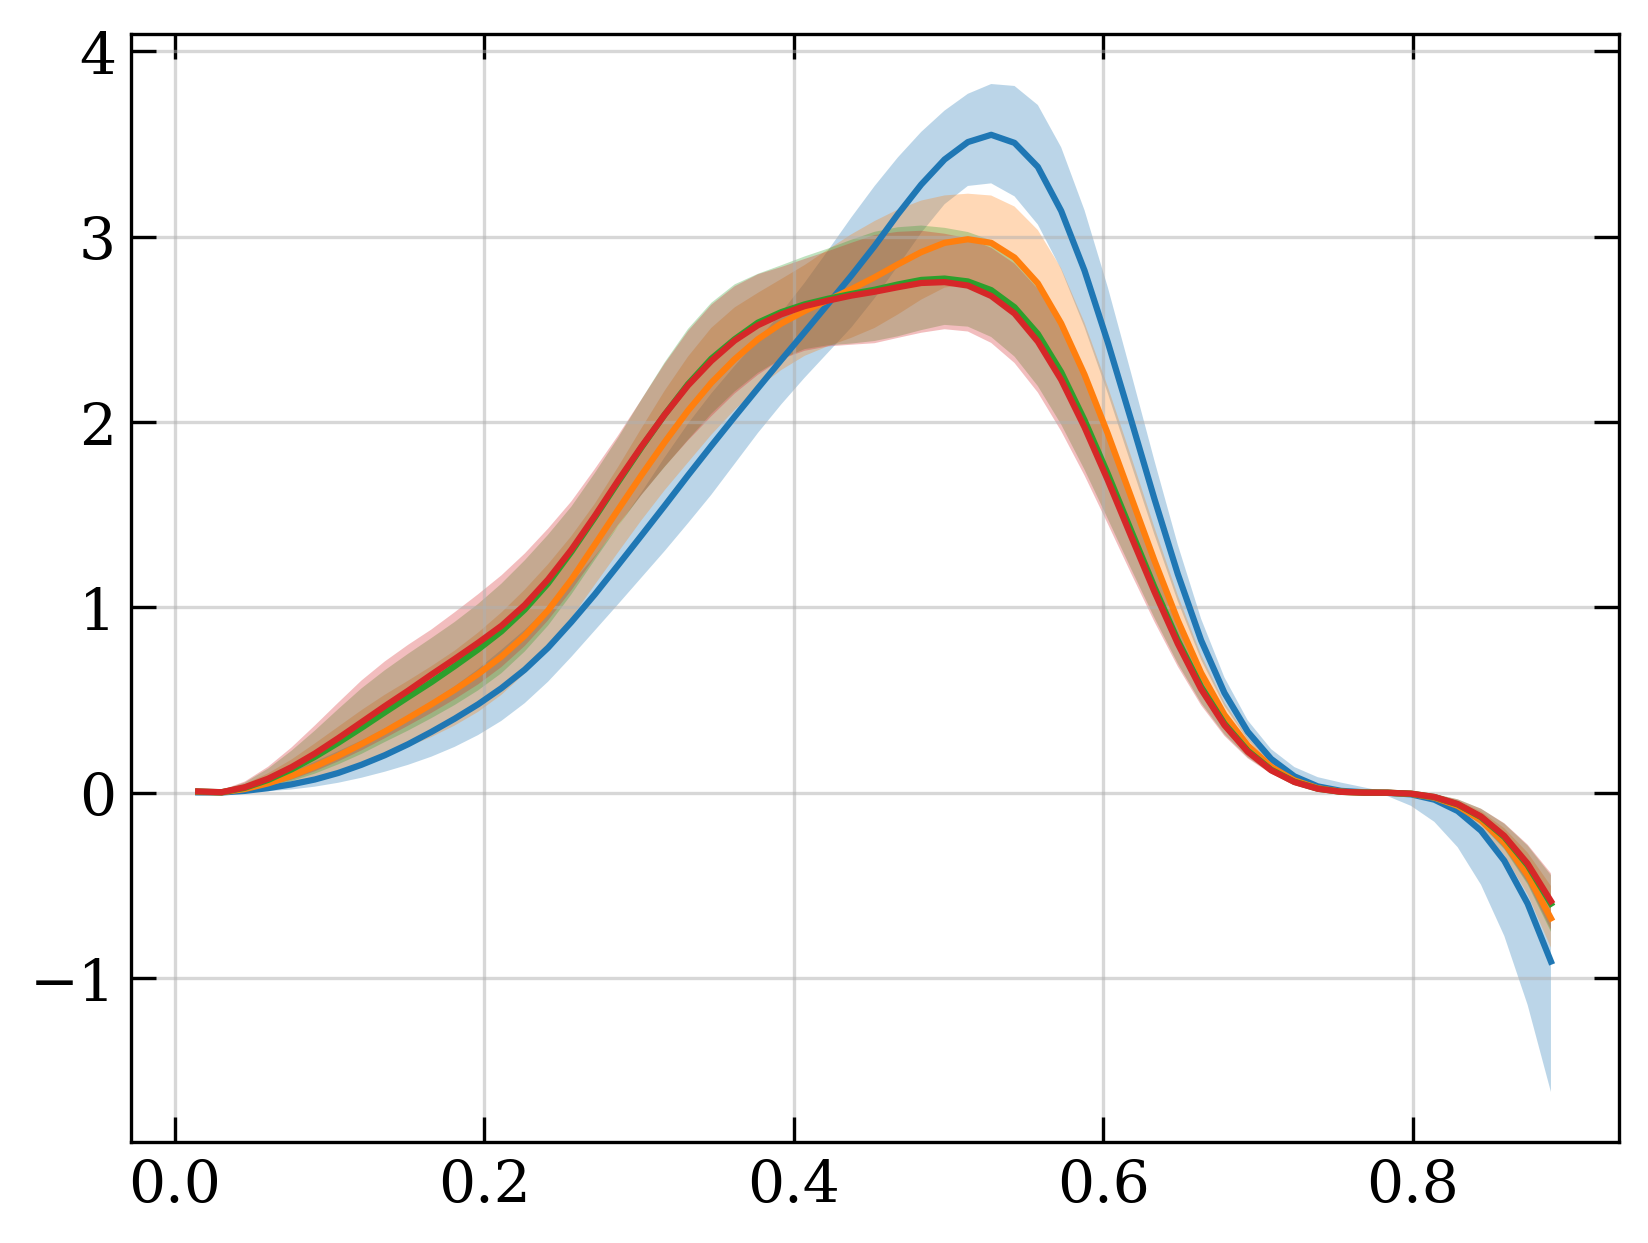

In [27]:
# save to file the sample draws 
for name in ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']:
    for tomo in range(1, 2):
        spl = splines_dict[name][tomo]
        z_eval_full = np.linspace(0, 3, 200)
        basis_eval = spl._create_evaluation_basis(z_eval_full)
        coeffs_samples = spl.coeffs_samples
        amplitude_samples = spl.amplitude_samples
        nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]
        mask = (z_eval_full > bounds[str(tomo)][0]) & (z_eval_full < bounds[str(tomo)][1])
        nz_samples_s = nz_samples_full[:, mask]
        z_eval = z_eval_full[mask]
        
        integ = np.trapezoid(np.percentile(nz_samples_s, 50, axis=0), z_eval)
        nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval) for nzs in nz_samples_s])

        nz_median = np.percentile(nz_samples, 50, axis=0) / integ
        nz_lower = np.percentile(nz_samples, 16, axis=0) / integ
        nz_upper = np.percentile(nz_samples, 84, axis=0) / integ
        
    plt.plot(z_eval, nz_median, label=f'Tomo {tomo}')
    plt.fill_between(z_eval, nz_lower, nz_upper, alpha=0.3)

In [28]:
with pm.make_plot(
    name=f'all_tomo_sp', show=True,
    figsize=(12, 7), ncols=2, nrows=2,
    sharey=True  # share y-axis
) as (fig, axs):
    axs = axs.flatten()

    for i, tomo in enumerate([1]):
        ax = axs[i]
        ax.grid(True)
        ax.axhline(0, color='black', alpha=0.7, linestyle='--')
        ax.set_xlim(bounds[str(tomo)])

        # --- Only outer labels ---
        if i in [2, 3]:  # bottom row
            ax.set_xlabel("Redshift (z)")
        if i in [0, 2]:  # left column
            ax.set_ylabel("p(z)")

        # --- Phot calibration (dnnz) ---
        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tomo], mids)
        ax.fill_between(
            mids,
            np.percentile(dnnz, 16, axis=0),
            np.percentile(dnnz, 84, axis=0),
            color='gray',
            hatch='//',
            alpha=0.2,
            label="Phot (16–84%)" if i == 0 else None
        )

        # --- Loop over raw + mag splines ---
        for index, label, splines, color, linestyle in [
            (0, "n(z) (median"+r'$\pm1\sigma$)', splines_dict['npz_bs_bp'], 'blue', '-'),
            (1, "n(z) "+r'$\mu-corr$', splines_dict['npz_bs_bp_mag'], 'red', '--'),
            (2, "n(z) "+r'$b_s$', splines_dict['npz_bs'], 'green', '-.')
        ]:
            spl = splines[tomo-1]
            z_eval_full = np.linspace(0, 3, 200)

            basis_eval = spl._create_evaluation_basis(z_eval_full)
            coeffs_samples = spl.coeffs_samples
            amplitude_samples = spl.amplitude_samples
            nz_samples_full = (coeffs_samples @ basis_eval.T) * amplitude_samples[:, np.newaxis]

            mask = (z_eval_full > bounds[str(tomo)][0]) & (z_eval_full < bounds[str(tomo)][1])
            nz_samples_s = nz_samples_full[:, mask]
            z_eval = z_eval_full[mask]

            nz_samples = np.array([nzs/np.trapezoid(nzs, z_eval) for nzs in nz_samples_s])
        
            integ = np.trapezoid(np.percentile(nz_samples_s, 50, axis=0), z_eval)
            nz_median = np.percentile(nz_samples, 50, axis=0) / integ
            nz_lower = np.percentile(nz_samples, 16, axis=0) / integ
            nz_upper = np.percentile(nz_samples, 84, axis=0) / integ

            ax.plot(
                z_eval,
                nz_median,
                color=color,
                alpha=1,
                linewidth=1.6,
                linestyle=linestyle
            )
            ax.fill_between(
                z_eval,
                nz_lower,
                nz_upper,
                color=color,
                alpha=0.2,
            )

            # --- Data points ---
            z_data = data[f'{tomo}/z']
            npz_data = data[f'{tomo}/{name}'] #/ integ
            npz_data_err = data[f'{tomo}/{name}_err'] #/ integ
            mask_data = (z_data > bounds[str(tomo)][0]) & (z_data < bounds[str(tomo)][1])

            ax.errorbar(
                z_data[mask_data], 
                npz_data[mask_data],
                yerr=npz_data_err[mask_data],
                fmt='s' if index==0 else 'd',
                color=color,
                capsize=3,
                ms=3.5,
                label=label if i == 0 else None
            )

        # --- Bin label in upper-right ---
        ax.text(
            0.95, 0.95, f"Bin {i+1}",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=14, 
        )

    # --- Legend only in first subplot ---
    axs[0].legend(
        loc='upper left',
        frameon=True,
        fontsize=11,
        title=f'Scale : [0.3–3] '+r'h$^{-1}$Mpc',
        title_fontsize=11
    )

KeyError: 0

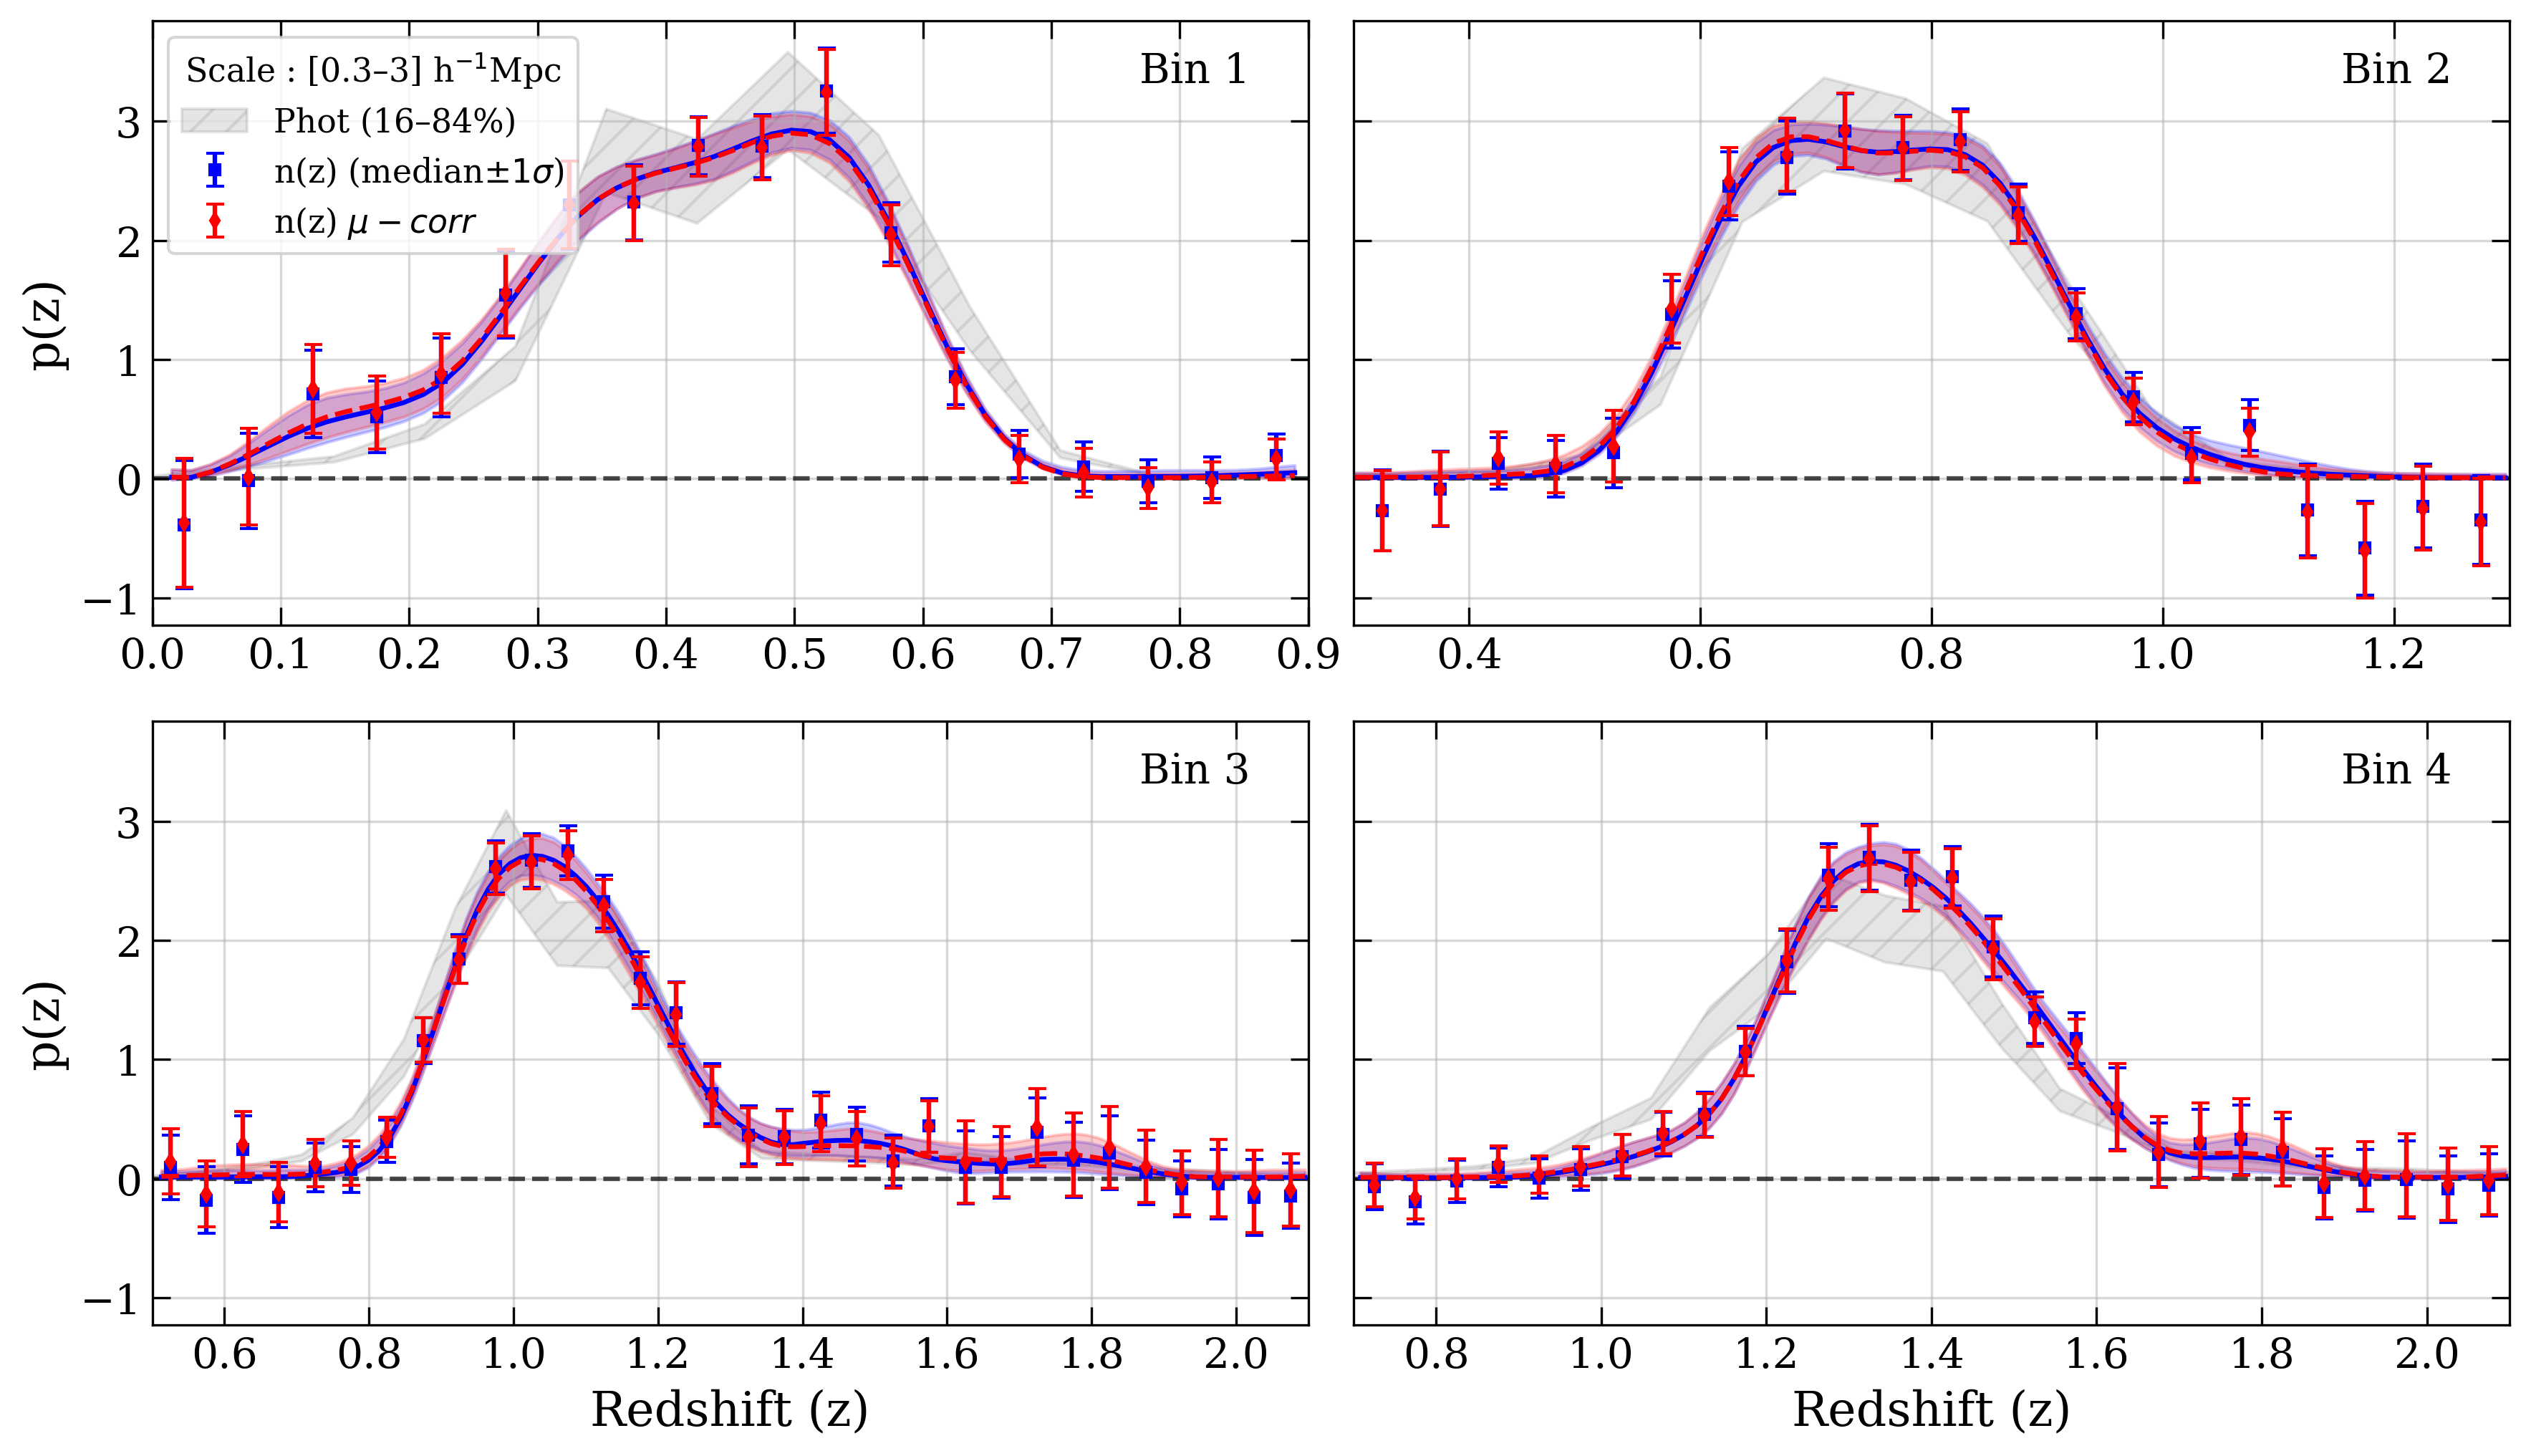](attachment:image.png)

In [39]:
print(expect)

{'1/npz_cross': array([0.45460254, 0.46108492, 0.46732704]), '1/npz_cross_mean': np.float64(0.4610244733558673), '1/npz_bs': array([0.43134004, 0.43886863, 0.44613542]), '1/npz_bs_mean': np.float64(0.43876368168702995), '1/npz_bs_bp': array([0.41815454, 0.42616472, 0.43437555]), '1/npz_bs_bp_mean': np.float64(0.42621637779756416), '1/npz_bs_bp_mag': array([0.4149503 , 0.42353688, 0.43201058]), '1/npz_bs_bp_mag_mean': np.float64(0.42348462242762824), '2/npz_cross': array([0.73338439, 0.73856419, 0.74397123]), '2/npz_cross_mean': np.float64(0.7386674802295097), '2/npz_bs': array([0.76356369, 0.77010785, 0.77726365]), '2/npz_bs_mean': np.float64(0.7703957962805903), '2/npz_bs_bp': array([0.75390282, 0.76072168, 0.76764574]), '2/npz_bs_bp_mean': np.float64(0.7607583661582946), '2/npz_bs_bp_mag': array([0.74897377, 0.75574738, 0.76279774]), '2/npz_bs_bp_mag_mean': np.float64(0.7558647553459179), '3/npz_cross': array([1.16221826, 1.19025435, 1.21901552]), '3/npz_cross_mean': np.float64(1.190

In [30]:
s_data.keys()

dict_keys(['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu'])

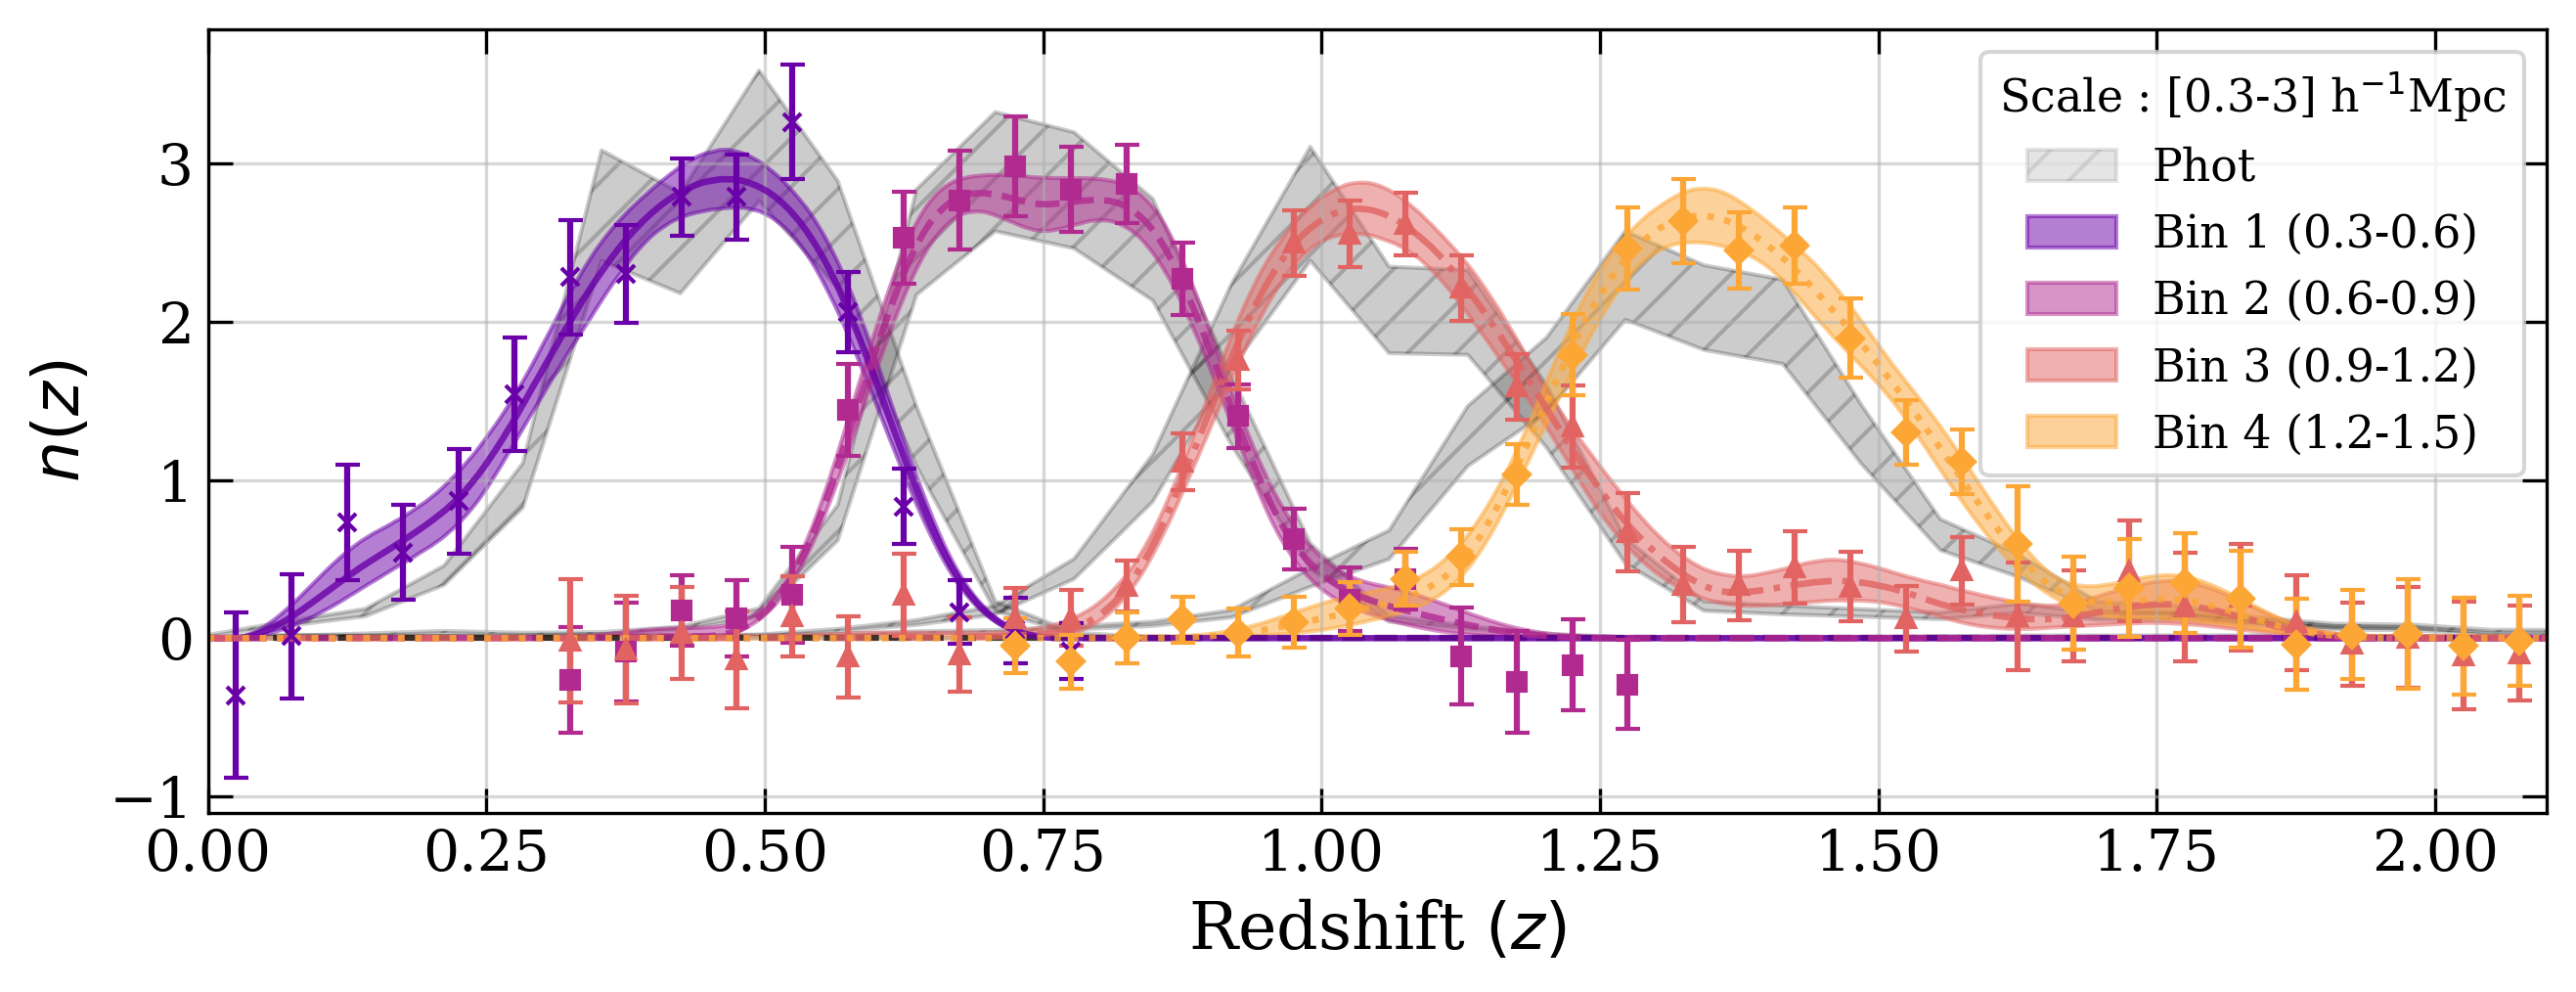

In [40]:
show_dnnz_phot = True

with pm.make_plot(name=f'all_tomo', show=True, figsize=(9, 3.6)) as (fig, ax):
    #ax.errorbar(z, npz_raw, yerr=npz_raw_err, fmt='d', color='b', capsize=3, label="No mag correction")
    #ax.errorbar(z, npz_mag, yerr=npz_mag_err, fmt='x', color='r', capsize=3, label="With mag correction")
    ax.grid(True)
    ax.axhline(0, color='black', alpha=0.7, linestyle='--')
    ax.set_xlabel(r"Redshift $(z)$",)
    ax.set_ylabel(r'$n(z)$')
    ax.set_xlim(0., 2.1)

    for tomo in [1, 2, 3, 4]:
        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tomo], mids)
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color='black', 
            hatch='//',
            alpha=0.2,
            )
    z_eval_full = s_data['z']
    
    for tomo in [1, 2, 3, 4]:
        
        nz_median = s_data[f'{tomo}/nz_median']
        nz_mean = s_data[f'{tomo}/nz_mean']
        nz_lower = s_data[f'{tomo}/nz_lower']
        nz_upper = s_data[f'{tomo}/nz_upper']

        col = cmap((tomo)/5)
        ax.plot(
            z_eval_full, 
            nz_median, 
            color=col, 
            alpha=0.8,
            linewidth=1.6, 
            linestyle=linestyles[tomo-1],
            )
        ax.fill_between(
            z_eval_full, 
            nz_lower, 
            nz_upper, 
            color=col, 
            alpha=0.5, 
            )
        
        z_data = data[f'{tomo}/npz_bs_bp_mag_z']
        npz_data = data[f'{tomo}/npz_bs_bp_mag']
        npz_data_err = data[f'{tomo}/npz_bs_bp_mag_err']
        mask_data = (z_data > bounds[str(tomo)][0]) & (z_data < bounds[str(tomo)][1])
        
        ax.errorbar(z_data[mask_data], npz_data[mask_data], yerr=npz_data_err[mask_data], fmt=markers[tomo-1], color=col, capsize=3, ms=4.5, alpha=1)
            
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = []
        legend_elements.append(
            Patch(
                facecolor='gray',
                edgecolor='gray',
                alpha=0.2,
                hatch='//',
                label="Phot"
            )
        )
        for tomo in [1, 2, 3, 4]:
            col = cmap((tomo)/5)
            legend_elements.append(
                Patch(
                    facecolor=col,
                    edgecolor=col,
                    alpha=0.5,
                    label=f'Bin {tomo} ({tomo*0.3:.1f}-{(tomo+1)*0.3:.1f})'
                )
            )
        ax.legend(
            handles=legend_elements,
            loc='upper right',
            frameon=True,
            fontsize=11,
            title=f'Scale : [0.3-3] '+r'h$^{-1}$Mpc',
            title_fontsize=11
        )
    #ax.legend(title=f'Bin {tomo}\nScale : [0.3-3] '+r'h$^{-1}$Mpc', loc='upper right')

Bin 1 [n(z)]: 16th=0.415, median=0.424, 84th=0.434 : 0.424 (+0.009, -0.009)
Bin 2 [n(z)]: 16th=0.752, median=0.759, 84th=0.767 : 0.759 (+0.008, -0.007)
Bin 3 [n(z)]: 16th=1.099, median=1.118, 84th=1.140 : 1.118 (+0.022, -0.020)
Bin 4 [n(z)]: 16th=1.365, median=1.377, 84th=1.391 : 1.377 (+0.014, -0.012)
Bin 1 [n(z) $\mu$-corr]: 16th=0.4116, median=0.4208, 84th=0.4296 : 0.421 (+0.009, -0.009)
Bin 2 [n(z) $\mu$-corr]: 16th=0.7471, median=0.7545, 84th=0.7623 : 0.755 (+0.008, -0.007)
Bin 3 [n(z) $\mu$-corr]: 16th=1.0986, median=1.1215, 84th=1.1455 : 1.121 (+0.024, -0.023)
Bin 4 [n(z) $\mu$-corr]: 16th=1.3650, median=1.3789, 84th=1.3935 : 1.379 (+0.015, -0.014)
Bin 1 [n(z) DNNz]: 16th=0.4563, median=0.4618, 84th=0.4673 : 0.462 (+0.005, -0.005)
Bin 2 [n(z) DNNz]: 16th=0.7608, median=0.7662, 84th=0.7715 : 0.766 (+0.005, -0.005)
Bin 3 [n(z) DNNz]: 16th=1.0772, median=1.0835, 84th=1.0899 : 1.083 (+0.006, -0.006)
Bin 4 [n(z) DNNz]: 16th=1.3242, median=1.3300, 84th=1.3359 : 1.330 (+0.006, -0.006) 
with bounds

without bounds :
Bin 1 [n(z)]: 16th=0.439, median=0.457, 84th=0.479 : 0.457 (+0.022, -0.018)
Bin 2 [n(z)]: 16th=0.734, median=0.750, 84th=0.763 : 0.750 (+0.014, -0.016)
Bin 3 [n(z)]: 16th=1.110, median=1.135, 84th=1.164 : 1.135 (+0.029, -0.025)
Bin 4 [n(z)]: 16th=1.362, median=1.385, 84th=1.407 : 1.385 (+0.022, -0.023)
Bin 1 [n(z) $\mu$-corr]: 16th=0.4325, median=0.4493, 84th=0.4698 : 0.449 (+0.021, -0.017)
Bin 2 [n(z) $\mu$-corr]: 16th=0.7287, median=0.7442, 84th=0.7576 : 0.744 (+0.013, -0.016)
Bin 3 [n(z) $\mu$-corr]: 16th=1.1172, median=1.1471, 84th=1.1817 : 1.147 (+0.035, -0.030)
Bin 4 [n(z) $\mu$-corr]: 16th=1.3661, median=1.3910, 84th=1.4173 : 1.391 (+0.026, -0.025)
Bin 1 [n(z) DNNz]: 16th=0.4565, median=0.4619, 84th=0.4673 : 0.462 (+0.005, -0.005)
Bin 2 [n(z) DNNz]: 16th=0.7607, median=0.7663, 84th=0.7718 : 0.766 (+0.006, -0.006)
Bin 3 [n(z) DNNz]: 16th=1.0773, median=1.0836, 84th=1.0898 : 1.084 (+0.006, -0.006)
Bin 4 [n(z) DNNz]: 16th=1.3243, median=1.3301, 84th=1.3361 : 1.330 (+0.006, -0.006)

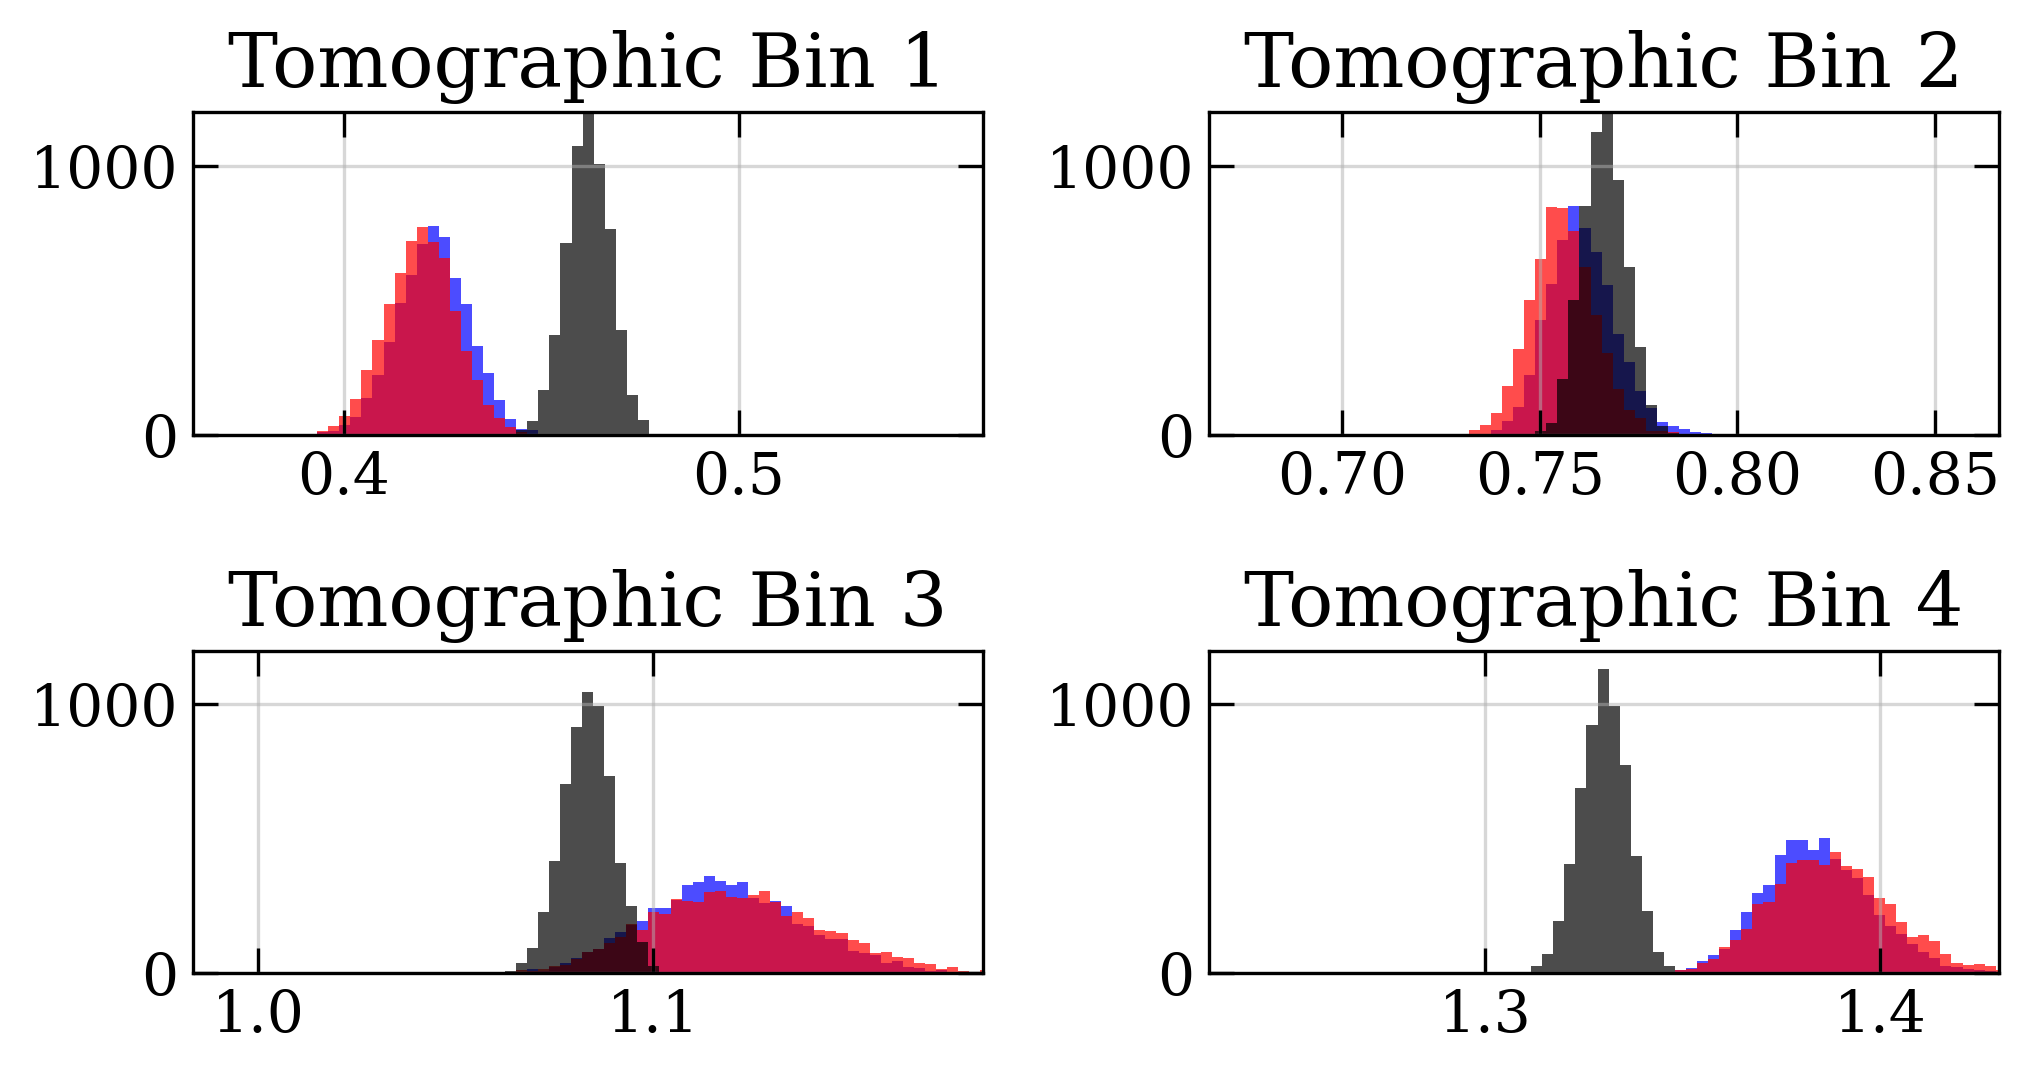

In [13]:
%pip install dill
import dill
save_splines = Path('splines')
save_splines.mkdir(exist_ok=True)
with open(save_splines / f'spline_raw_{tomo}.pkl', 'wb') as f:
    dill.dump(spl_raw_1, f)
with open(save_splines / f'spline_mag_{tomo}.pkl', 'wb') as f:
    dill.dump(spl_mag_1, f)

Note: you may need to restart the kernel to use updated packages.
